In [21]:
import numpy as np
import matplotlib.pyplot as plt

# On fixe la seed pour que nos résultats soient reproductibles
np.random.seed(42)
print("Setup terminé ✓")

Setup terminé ✓


In [22]:
class RandomWalkEnv:
    """
    Environnement de la marche aléatoire à 5 états.
    Positions : 0=FIN gauche, 1=A, 2=B, 3=C, 4=D, 5=E, 6=FIN droite
    """
    
    def __init__(self):
        self.n_states = 7  # 0 à 6
        self.start_position = 3  # on démarre toujours à C
        self.position = self.start_position
    
    def reset(self):
        """Remet l'agent au centre (état C) pour démarrer un nouvel épisode."""
        self.position = self.start_position
        return self.position
    
    def step(self):
        """
        Fait avancer l'agent d'un pas ALÉATOIRE (gauche ou droite, 50/50).
        Retourne : (nouvel état, reward, episode_termine)
        """
        # Tirage aléatoire : -1 (gauche) ou +1 (droite), équiprobable
        move = np.random.choice([-1, 1])
        self.position += move
        
        # Vérifier si on a atteint un état terminal
        if self.position == 6:
            return self.position, 1.0, True  # FIN droite : reward = 1
        elif self.position == 0:
            return self.position, 0.0, True  # FIN gauche : reward = 0
        else:
            return self.position, 0.0, False  # partie continue, reward = 0

In [23]:
# Test manuel : on simule un épisode et on affiche chaque étape
env = RandomWalkEnv()
state = env.reset()
print(f"Départ : position {state}")

n_steps = 0
done = False

while not done:
    n_steps = n_steps + 1
    state, reward, done = env.step()
    print(f"Nouvelle position : {state}, reward : {reward}, terminé : {done}")

if reward == 1.0 :
    resultat = "Victoire !"
else :
    resultat = "Défaite :("

print(f"Nombre de tours : {n_steps} et le résultat est : {resultat}")
    

Départ : position 3
Nouvelle position : 2, reward : 0.0, terminé : False
Nouvelle position : 3, reward : 0.0, terminé : False
Nouvelle position : 2, reward : 0.0, terminé : False
Nouvelle position : 1, reward : 0.0, terminé : False
Nouvelle position : 0, reward : 0.0, terminé : True
Nombre de tours : 5 et le résultat est : Défaite :(


In [24]:
# Hyperparamètres
alpha = 0.1
n_episodes = 200

# Initialisation de V
V = np.ones(7) * 0.5
V[0] = 0.0
V[6] = 1.0

# NOUVEAU : une liste pour stocker une COPIE de V à chaque épisode
historique_V = [V.copy()]

env = RandomWalkEnv()
print("V au tout début de cette exécution :", np.round(V, 3))
for episode in range(n_episodes):
    state = env.reset()
    done = False
    
    while not done:
        old_state = state
        state, reward, done = env.step()
        
        if done:
            V[old_state] = V[old_state] + alpha * (reward - V[old_state])
        else:
            V[old_state] = V[old_state] + alpha * (V[state] - V[old_state])
    
    # NOUVEAU : à la fin de CHAQUE épisode, on sauvegarde une photo de V
    historique_V.append(V.copy())
print("Nombre de photos sauvegardées :", len(historique_V))
print(V)

V au tout début de cette exécution : [0.  0.5 0.5 0.5 0.5 0.5 1. ]
Nombre de photos sauvegardées : 201
[0.         0.15772762 0.27463309 0.46050601 0.68454556 0.84674068
 1.        ]


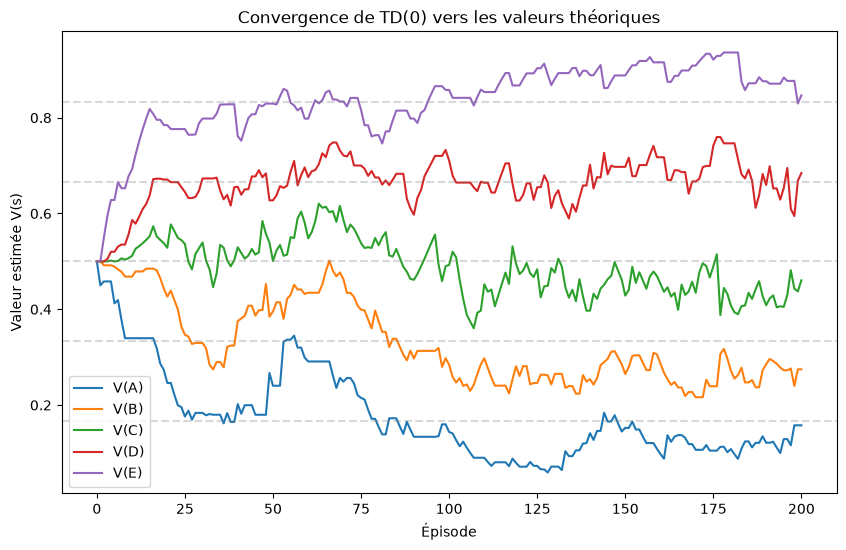

In [25]:
# On convertit la liste de tableaux en un seul gros tableau 2D
# Chaque ligne = un épisode, chaque colonne = un état
historique_V = np.array(historique_V)

plt.figure(figsize=(10, 6))

# On trace une courbe par état non-terminal (A, B, C, D, E)
labels = ['A', 'B', 'C', 'D', 'E']
for i, label in enumerate(labels):
    indice_etat = i + 1  # A=1, B=2, C=3, D=4, E=5
    plt.plot(historique_V[:, indice_etat], label=f"V({label})")

# Lignes horizontales pour les vraies valeurs théoriques
valeurs_theoriques = [1/6, 2/6, 3/6, 4/6, 5/6]
for v_theo in valeurs_theoriques:
    plt.axhline(y=v_theo, color='gray', linestyle='--', alpha=0.3)

plt.xlabel("Épisode")
plt.ylabel("Valeur estimée V(s)")
plt.title("Convergence de TD(0) vers les valeurs théoriques")
plt.legend()
plt.show()

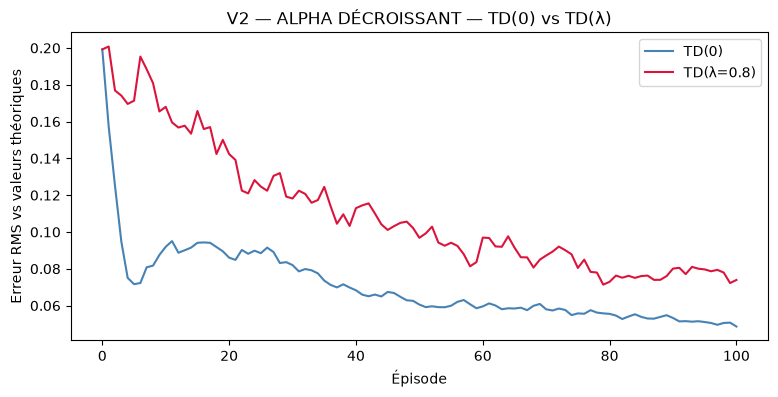

Erreur finale TD(0)  : 0.0486
Erreur finale TD(λ)  : 0.0739


In [26]:
# ============================================================
# TD(0) vs TD(lambda) — VERSION UNIQUE ET AUTONOME
# Tout est dans cette cellule : fonction + comparaison + graphique
# ============================================================

def td_lambda_v2(n_episodes=100, alpha_debut=0.5, lam=0.8):
    """TD(lambda) avec alpha DECROISSANT au fil des episodes."""
    V = np.ones(7) * 0.5
    V[0], V[6] = 0.0, 1.0
    historique = [V.copy()]
    env = RandomWalkEnv()
    
    for episode in range(n_episodes):
        alpha = alpha_debut / (1 + episode * 0.05)   # decroissance
        state = env.reset()
        done = False
        traces = np.zeros(7)
        
        while not done:
            old_state = state
            state, reward, done = env.step()
            delta = (reward - V[old_state]) if done else (V[state] - V[old_state])
            traces = lam * traces
            traces[old_state] += 1
            V = V + alpha * delta * traces
            V[0], V[6] = 0.0, 1.0
        
        historique.append(V.copy())
    
    return np.array(historique)


# --- Comparaison sur 50 runs ---
V_theorique = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 1])
n_episodes, n_runs = 100, 50

err_td0 = np.zeros(n_episodes + 1)
err_lam = np.zeros(n_episodes + 1)

for run in range(n_runs):
    h0 = td_lambda_v2(n_episodes, alpha_debut=0.5, lam=0.0)
    hl = td_lambda_v2(n_episodes, alpha_debut=0.5, lam=0.8)
    err_td0 += np.sqrt(np.mean((h0 - V_theorique)**2, axis=1))
    err_lam += np.sqrt(np.mean((hl - V_theorique)**2, axis=1))

err_td0 /= n_runs
err_lam /= n_runs

# --- Graphique avec titre DISTINCTIF pour confirmer la bonne version ---
plt.figure(figsize=(9, 4))
plt.plot(err_td0, label="TD(0)", color='steelblue')
plt.plot(err_lam, label="TD(λ=0.8)", color='crimson')
plt.xlabel("Épisode")
plt.ylabel("Erreur RMS vs valeurs théoriques")
plt.title("V2 — ALPHA DÉCROISSANT — TD(0) vs TD(λ)")
plt.legend()
plt.show()

print("Erreur finale TD(0)  :", round(err_td0[-1], 4))
print("Erreur finale TD(λ)  :", round(err_lam[-1], 4))

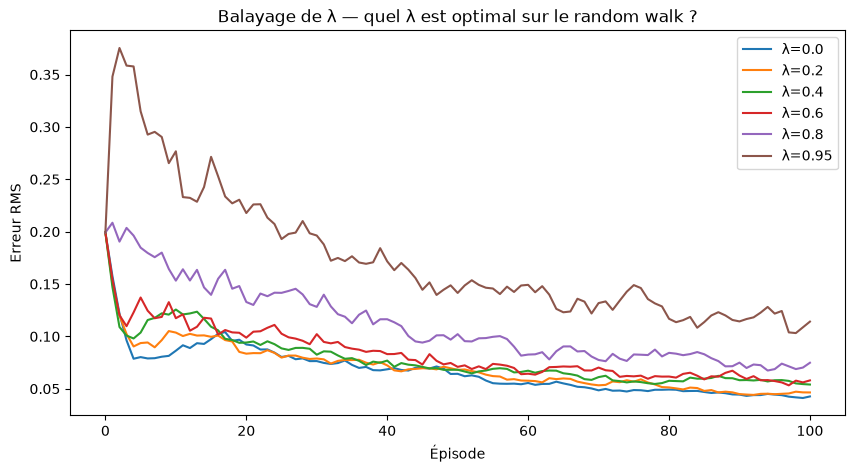

In [27]:
lambdas = [0.0, 0.2, 0.4, 0.6, 0.8, 0.95]
n_episodes, n_runs = 100, 50
V_theorique = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 1])

plt.figure(figsize=(10, 5))

for lam in lambdas:
    erreurs = np.zeros(n_episodes + 1)
    for run in range(n_runs):
        h = td_lambda_v2(n_episodes, alpha_debut=0.5, lam=lam)
        erreurs += np.sqrt(np.mean((h - V_theorique)**2, axis=1))
    erreurs /= n_runs
    plt.plot(erreurs, label=f"λ={lam}")

plt.xlabel("Épisode")
plt.ylabel("Erreur RMS")
plt.title("Balayage de λ — quel λ est optimal sur le random walk ?")
plt.legend()
plt.show()